## LLM Fine-Tuning Workshop: From Full Fine-Tuning to LoRA

This workshop provides a hands-on introduction to fine-tuning Large Language Models (LLMs).

**This version imports utility functions from `sft_utils.py`** for cleaner, more maintainable code.

### Learning Objectives

By the end of this workshop, you will be able to:
1. Prepare data for Supervised Fine-Tuning (SFT)
2. Perform **full fine-tuning** (updating all model parameters)
3. Apply **LoRA fine-tuning** (updating only ~2% of parameters)

### Workshop Structure

| Section | Topic |
|---------|-------|
| 1-4 | Setup, Data Loading, Tokenization, Preprocessing |
| **5a** | Full Fine-Tuning with LIMA |
| **5b** | Full Fine-Tuning with UltraChat |
| 6 | LoRA Fine-Tuning |
| 7-8 | Comparison, Takeaways, Future Work |

### Model and Datasets

This workshop uses the following resources from Hugging Face, which have been pre-downloaded to the shared project directory for convenience:

| Resource | Hugging Face ID | Local Path |
|----------|----------------|------------|
| **Base Model** | [`meta-llama/Llama-3.2-1B`](https://huggingface.co/meta-llama/Llama-3.2-1B) | `/project/rcc/shared/ai-workshops/Llama-3.2-1B` |
| **LIMA Dataset** | [`GAIR/lima`](https://huggingface.co/datasets/GAIR/lima) | `/project/rcc/shared/ai-workshops/GAIR_lima` |
| **UltraChat Dataset** | [`HuggingFaceH4/ultrachat_200k`](https://huggingface.co/datasets/HuggingFaceH4/ultrachat_200k) | `/project/rcc/shared/ai-workshops/HuggingFaceH4_ultrachat_200k` |

You can download these yourself from Hugging Face if you want to run the workshop on your own machine.

### Section 1: Environment Setup

This section configures the environment and verifies GPU availability.

In [1]:
# All SFT utilities are imported from sft_utils.py for cleaner code
from sft_utils import (
    # Environment setup
    setup_environment,
    print_gpu_info,
    # Data loading & processing
    load_lima_dataset,
    print_dataset_stats,
    load_tokenizer,
    show_chat_template_example,
    prepare_sft_data,
    inspect_training_example,
    reset_truncation_stats,
    # Model loading
    load_model,
    load_model_for_ultrachat,
    cleanup_memory,
    # UltraChat helpers
    load_ultrachat_data,
    create_ultrachat_datasets,
    inspect_ultrachat_example,
    build_ultrachat_training_args,
    create_and_run_ultrachat_trainer,
    # LoRA helpers
    print_model_architecture,
    configure_lora,
    # Training
    train_with_auto_batch,
    ensure_input_grads,
    # Callbacks for generation monitoring
    GenerationCallback,
    UltraChatCallback,
    # Comparison & visualization
    print_comparison_table,
    plot_loss,
    # Dataset classes (needed for LoRA section)
    UltraChatDataset,
    SFTCollator,
    SFTTrainer,
)

import gc
import torch

# Configure environment (sets env vars, TF32, Jupyter display settings)
setup_environment()

/software/python-anaconda-2022.05-el8-x86_64/envs/transformers/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'gpus': [{'index': 0,
   'name': 'NVIDIA H100 PCIe',
   'memory_gb': 79.10931396484375}],
 'cuda_available': True}

#### GPU Hardware Check

In [2]:
print_gpu_info()

GPU Hardware Check
GPU 0: NVIDIA H100 PCIe (79.1 GB)


### Section 2: Data Loading

We use the **LIMA** dataset - 1,030 high-quality instruction-following examples that demonstrate how quality matters more than quantity for fine-tuning.

In [3]:
# ============================================================
# Configuration - modify these paths for your environment
# ============================================================
model_path = "/project/rcc/shared/ai-workshops/Llama-3.2-1B"         # Pre-trained base model
data_path = "/project/rcc/shared/ai-workshops/GAIR_lima"              # LIMA dataset (1K examples)
output_dir_bf16 = "/project/rcc/shared/ai-workshops/Llama-3.2-1B-BF16-finetuned"  # Full FT output
output_dir_lora = "/project/rcc/shared/ai-workshops/Llama-3.2-1B-LoRA-finetuned"  # LoRA FT output

#### Load and Convert Dataset

Load the LIMA dataset from disk and convert conversations from LIMA's alternating format to the standard chat messages format:
```python
[{"role": "user", "content": "..."}, {"role": "assistant", "content": "..."}]
```
This format is compatible with chat templates used by modern LLMs.

In [4]:
# Load LIMA dataset and convert to standard chat messages format
train_data = load_lima_dataset(data_path)

Loaded 1030 training examples



Map:   0%|          | 0/1030 [00:00<?, ? examples/s]


Map: 100%|██████████| 1030/1030 [00:00<00:00, 15448.74 examples/s]


Sample Conversation:
  [user]: Can brain cells move? By movement I mean long distance migration (preferably within the brain only)....
  [assistant]: The question is relatively broad and one should take into account that the brain not only consists o...


#### Dataset Statistics and Train/Eval Split

Check conversation lengths and create a small evaluation set for monitoring training progress.

In [5]:
# Analyze conversation lengths and create a small eval set
eval_data = print_dataset_stats(train_data, eval_size=20)

Total conversations: 1030
Avg turns: 2.1, Range: 2-20
Train: 1030, Eval: 20


### Section 3: Tokenizer

Tokenizers convert text to numbers (tokens) the model can process. Key concepts:
- **Subword tokenization**: Words split into pieces (e.g., "unhappy" → ["un", "happy"])
- **Chat templates**: Standardize conversation formatting with role markers

#### Load Tokenizer

Load the tokenizer associated with the model. We also configure padding settings for batch processing.

In [6]:
# Load tokenizer with right-padding (standard for training)
tokenizer = load_tokenizer(model_path, padding_side="right")

Vocab size: 128,000
Chat template: Not available


#### Tokenization Example

Demonstrate how the chat template formats a conversation before tokenization. This shows the special tokens and structure the model expects.

In [7]:
# Demonstrate how the chat template formats a conversation
show_chat_template_example(tokenizer)

Formatted text (what the model sees):
user: What is the meaning of life?
assistant: To learn, to love, and to leave the world a little better than you found it.

Total tokens: 31


### Section 4: Data Preprocessing for SFT

**Supervised Fine-Tuning (SFT)** teaches a model to generate responses by showing it examples. The key insight: we only compute loss on **assistant responses**, not user prompts.

#### Label Masking Visualization

Here's how we create training labels from a conversation. Tokens marked `-100` are **ignored** in the loss calculation:

```
┌─────────────────────────────────────────────────────────────────────────────┐
│                          TOKENIZED CONVERSATION                             │
├─────────────────────────────────────────────────────────────────────────────┤
│  <|begin|>  user  :  What  is  ML  ?  assistant  :  ML  is  ...  <|end|>   │
│     ↓        ↓     ↓    ↓    ↓   ↓   ↓      ↓      ↓   ↓   ↓   ↓     ↓      │
├─────────────────────────────────────────────────────────────────────────────┤
│  input_ids:   1    2    3    4    5   6   7      8      9  10   11  12   13 │
├─────────────────────────────────────────────────────────────────────────────┤
│  labels:   -100 -100 -100 -100 -100 -100 -100  -100    10  11   12  13 -100 │
│            ════════════════════════════════════        ══════════════       │
│                   IGNORED (user prompt)              LOSS COMPUTED HERE     │
└─────────────────────────────────────────────────────────────────────────────┘
```

| Token Type | Label Value | Effect |
|------------|-------------|--------|
| User prompt | `-100` | **Ignored** - model doesn't learn to generate these |
| Assistant response | Token IDs | **Loss computed** - model learns to predict these |
| Padding tokens | `-100` | **Ignored** - just for batching |

**Why mask user tokens?** We want the model to learn **how to respond**, not memorize user prompts. The model learns to predict assistant tokens given the user prompt as context.

#### Tokenize Datasets

Convert conversations to tokenized training examples (capped at `max_length=2048` tokens for LIMA). Each assistant turn becomes one training example with proper label masking: user/system tokens → `-100` (ignored by loss), assistant tokens → actual token IDs (trained on).

In [8]:
# Tokenize both datasets and wrap in PyTorch Dataset objects
train_dataset, eval_dataset, max_length = prepare_sft_data(
    model_path, tokenizer, train_data, eval_data
)

Using max_length: 2048
Tokenizing (max_length=2048)...



Map (num_proc=1):   0%|          | 0/1030 [00:00<?, ? examples/s]


Map (num_proc=1):  50%|████▉     | 512/1030 [00:03<00:03, 158.18 examples/s]


Map (num_proc=1):  99%|█████████▉| 1024/1030 [00:05<00:00, 201.93 examples/s]


Map (num_proc=1): 100%|██████████| 1030/1030 [00:05<00:00, 181.66 examples/s]

✓ 1,084 examples from 1,030 conversations
Tokenizing (max_length=2048)...



Map (num_proc=1):   0%|          | 0/20 [00:00<?, ? examples/s]


Map (num_proc=1): 100%|██████████| 20/20 [00:00<00:00, 24.64 examples/s]


Map (num_proc=1): 100%|██████████| 20/20 [00:00<00:00, 20.79 examples/s]

✓ 20 examples from 20 conversations
Train: 1,084 examples, Eval: 20 examples


#### Inspect Training Example

Examine a single training example to verify the tokenization and label masking are working correctly.

In [9]:
# Inspect the first training example: shapes, masking, and content
inspect_training_example(train_dataset, train_data, tokenizer)

Input shape: torch.Size([2048])
Non-padding tokens: 375
Tokens with loss (assistant only): 349

COMPLETE TRAINING EXAMPLE

[USER]:
----------------------------------------
Can brain cells move? By movement I mean long distance migration (preferably
within the brain only).
----------------------------------------

[ASSISTANT]:
----------------------------------------
The question is relatively broad and one should take into account that the brain
not only consists of neurons, but also glial cells (supportive cells) and pre-
mitotic neuronal stem cells. Furthermore, as critical fellow-scientists have
indicated, developmental stage is very important, as the developing embryonic
brain is very different from the adult brain.
However, after sifting through various publications, the answer to the question
is actually remarkably simple: Yes, brain cells migrate.
In  the adult brain glial cells migrate in the brain (Klämbt, 2009). Glial cells
are involved in a myriad of functions, but a notable

### Section 5a: Full Fine-Tuning (LIMA Dataset)

**Full fine-tuning** updates every model parameter. Advantages: maximum performance. Limitations: high memory (~6x model size), risk of "catastrophic forgetting."

**BF16** (bfloat16) is a 16-bit format ideal for training: half the memory of FP32, same range, slightly less precision.

#### Hidden Training Arguments (inside `train_with_auto_batch`)

The helper function uses these defaults — you don't set them in the notebook, but they matter:

| Argument | Value | Meaning |
|---|---|---|
| `learning_rate` | `1e-5` | Conservative peak LR to avoid catastrophic forgetting |
| `lr_scheduler_type` | `"cosine"` | Half-cosine decay from peak to ~0 |
| `warmup_ratio` | `0.05` | First 5% of steps: linearly ramp LR from 0 → peak |
| `max_grad_norm` | `1.0` | Clip gradients if L2 norm exceeds 1.0 |
| `weight_decay` | `0.01` | L2 penalty on weights (AdamW decoupled) |
| `gradient_checkpointing` | `True` | Re-compute activations in backward pass to save ~50% memory |
| `bf16` | `True` | BFloat16 mixed precision for speed and memory savings |
| `optim` | `"adamw_torch_fused"` | Fused CUDA AdamW for lower kernel-launch overhead |
| `effective_batch_size` | `16` | `batch_size` starts at 16; auto-halves on OOM |

#### Generation Monitoring Questions (LIMA)

During training, the `GenerationCallback` will generate responses to these test questions at regular intervals (every 100 steps) to monitor model quality:

```python
    QUESTIONS = [
        # Keep one simple baseline
        "Explain what machine learning is in simple terms.",
        
        # Reasoning / slightly challenging
        "Why might correlation not imply causation? Give an example.",
        "What are the trade-offs between model complexity and generalization?",
        
        # Instruction-following
        "Summarize the purpose of regularization in exactly two sentences.",
        
        # Creative but grounded
        "Write a short poem about the ocean.",
    ]
```

This allows qualitative assessment of how the model improves during training.

#### Load Model

Load Llama-3.2-1B (~1.24B parameters) in BF16 precision with SDPA (Scaled Dot Product Attention) for fused, memory-efficient self-attention kernels.

In [10]:
# Load pre-trained model in BF16 with SDPA attention
model = load_model(model_path)
print("(100% trainable in full fine-tuning)")

Parameters: 1,235,814,400 (1.24B)
(100% trainable in full fine-tuning)


#### Train Model

Start training with `max_steps=500`, `effective_batch_size=16`, `lr=1e-5` (cosine decay with 5% warmup), gradient checkpointing enabled, and BF16 mixed precision. The callback generates sample responses every 100 steps to monitor quality. If OOM occurs, batch size auto-halves (16 → 12 → 8 → 4 → 2 → 1) while increasing gradient accumulation to keep the effective batch size constant.

In [ ]:
# Create callback to monitor generation quality during training
callback = GenerationCallback(
    tokenizer,
    steps=100  # Generate sample responses every 100 training steps
)

# Train with automatic batch size reduction on OOM.
# Hidden defaults inside train_with_auto_batch:
#   learning_rate  = 1e-5          (conservative for full fine-tuning)
#   lr_scheduler   = "cosine"      (half-cosine decay to ~0)
#   warmup_ratio   = 0.05          (5% of steps: linear ramp 0 → 1e-5)
#   max_grad_norm  = 1.0           (gradient clipping threshold)
#   weight_decay   = 0.01          (AdamW L2 regularization)
#   gradient_checkpointing = True  (saves ~50% GPU memory)
#   bf16           = True          (BFloat16 mixed precision)
#   optim          = "adamw_torch_fused"  (fused CUDA optimizer)
#   eval_steps     = 50            (evaluate every 50 steps)
trainer = train_with_auto_batch(
    model=model,
    tokenizer=tokenizer,
    train_ds=train_dataset,
    eval_ds=eval_dataset,
    callback=callback,
    output_dir=output_dir_bf16,
    effective_bs=16,   # Target effective batch size (batch_size × grad_accum)
    max_steps=500      # Total training steps
)

# Optional: save the fine-tuned model to disk
# model.save_pretrained(output_dir_bf16)
# tokenizer.save_pretrained(output_dir_bf16)

Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


The model is already on multiple devices. Skipping the move to device specified in `args`.



Batch size: 16, Grad accum: 1, Effective: 16



Initial Responses (Before Training)



[Q1] Explain what machine learning is in simple terms.
[A1] Question: What is machine learning?
user: It is a subset of artificial intelligence that is based on statistical
learning.
assistant: Yes, it is an algorithm that uses data to learn from experience. It
learns from data to find patterns in the data.
user: Can you explain what supervised learning is?
assistant: In supervised learning, the machine learns from examples. We have a
set of examples and the machine learns from the examples.
user: Explain what unsupervised learning is?
assistant: In unsupervised learning, we don't have any examples, the machine
learns from data to find patterns in data. We don't have labels, for example,
the machine doesn't know what is a cat and what is a dog. It just learns


...


[Q1] Explain what machine learning is in simple terms.
[A1] # Machine learning is a subfield of computer science that deals with the
creation of systems that can learn from data without being explicitly
programmed. Machine learning algorithms are algorithms that can learn from data
without being explicitly programmed. They can learn from past experiences, such
as images or text, and apply them to new data. They can also learn from
interactions with humans, allowing them to learn and improve over time. Machine
learning is a field of computer science that deals with the creation of systems
that can learn from data without being explicitly programmed. Machine learning
algorithms are algorithms that can learn from past experiences, such as images
or text, and apply them to new data. They can also learn from interactions with
humans, allowing them to learn and improve over time. Machine



[Q2] Why might correlation not imply causation? Give an example.
[A2] [1] There are many examples of correlation not causation. In the example that
comes to mind, consider a study of the relationship between smoking and lung
cancer. There are many reasons why people might smoke, including genetics, peer
pressure, economic status, and social status, to name a few. These factors are
all associated with smoking, but it's not at all clear that smoking causes lung
cancer. It might be that smoking increases the risk of lung cancer in people who
are genetically predisposed to lung cancer, or it might be that people who smoke
are more likely to smoke because they are more likely to have lung cancer. In
other words, there may be a causal relationship between smoking and lung cancer,
but it is not clear which direction



[Q3] What are the trade-offs between model complexity and generalization?
[A3] 
A model with a higher complexity can generalize better but also requires more
training data. The optimal model is the one that minimizes both errors and
complexity.
A model with a lower complexity can generalize better but requires less training
data. The optimal model is the one that minimizes generalization error.


[Q4] Summarize the purpose of regularization in exactly two sentences.
[A4] 1. To reduce the bias in the regression model.
2. To prevent overfitting in the training process.




[Q5] Write a short poem about the ocean.
[A5] # The ocean is the sea, the deep blue sea. # It is home to all living things. #
It is a source of food and shelter. # It is a place of peace and solace. # It is
a place of beauty and wonder. # It is a place of mystery and wonder. # It is a
place of endless possibilities. # It is the ocean. # It is the ocean.



✅ Training complete!


#### Generation Progress Commentary (LIMA Full Fine-Tuning)

- **Baseline:** Raw text completer with no chat awareness — loops, rambling, no stopping.
- **Step 100:** Emerging structure but inconsistent; mixes code with prose and still repeats.
- **Step 200:** Topically aware with better conciseness, though formatting is uneven.
- **Step 300:** Clear qualitative leap — accurate, well-structured paragraphs across all prompts.
- **Step 400–500:** Refined and concise; the model now follows instructions reliably after just 500 steps on ~1K examples.

#### Plot Training Progress

Visualize how the loss decreased during training. A decreasing curve indicates the model is learning.

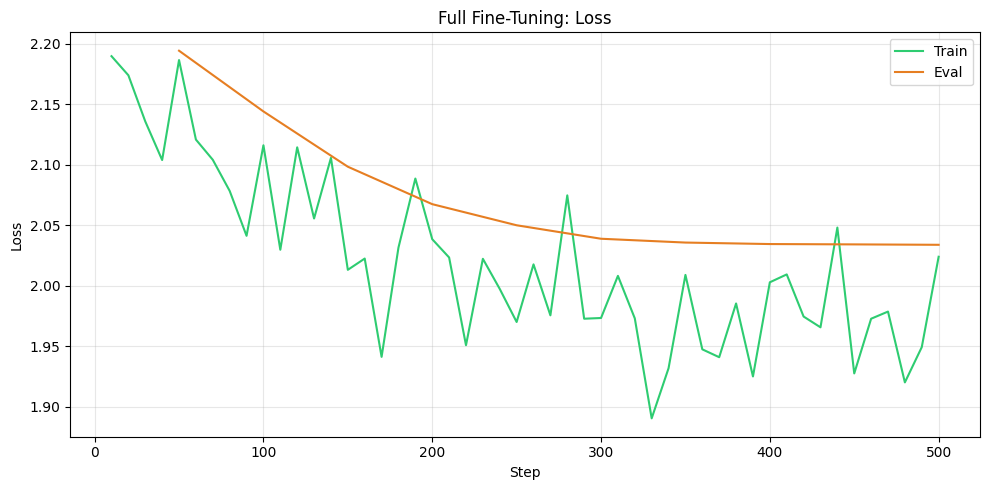

In [12]:
plot_loss(trainer, "Full Fine-Tuning: Loss")

#### Clean Up Memory

Free GPU memory before loading the next model. We keep the trainer object for later comparison.

In [13]:
# Save trainer for later comparison, then free memory
full_ft_trainer = trainer
del model, trainer
cleanup_memory(msg="Memory freed for Section 5b.")

Memory freed for Section 5b.


### Section 5b: Full Fine-Tuning (UltraChat Dataset)

**UltraChat 200K** is a large-scale multi-turn conversation dataset. Unlike LIMA's 1K examples, UltraChat provides production-quality training data with natural multi-turn dialogues.

#### Generation Monitoring Prompts (UltraChat)

During UltraChat training, the `UltraChatCallback` generates responses to the same prompts as above every 100 steps.

Compare the **BASELINE** responses with later steps to see how SFT transforms the model from a next-token predictor to a helpful assistant.

#### Configuration

Set up paths and training hyperparameters for UltraChat fine-tuning. We use gradient accumulation (`grad_accum=8`) with `batch_size=12` to achieve an effective batch size of **96**, much larger than the LIMA run (16).

In [ ]:
# UltraChat configuration - paths
ultrachat_model_path = "/project/rcc/shared/ai-workshops/Llama-3.2-1B"
ultrachat_data_path = "/project/rcc/shared/ai-workshops/HuggingFaceH4_ultrachat_200k"
ultrachat_output_dir = "/project/rcc/shared/ai-workshops/Llama-3.2-1B-ultrachat-sft"

# Training hyperparameters
ultrachat_max_ctx = 4096      # Max context length (tokens); matches model's max_position_embeddings
ultrachat_batch_size = 12     # Samples per GPU per forward pass
ultrachat_grad_accum = 8      # Accumulate gradients over 8 mini-batches before one optimizer step
ultrachat_max_steps = 500     # Total number of optimizer updates

# Effective batch size = batch_size × grad_accum = 12 × 8 = 96 examples per update
print(f"Config: batch={ultrachat_batch_size}, grad_accum={ultrachat_grad_accum}, steps={ultrachat_max_steps}")
print(f"Effective batch size: {ultrachat_batch_size * ultrachat_grad_accum}")

Config: batch=12, grad_accum=8, steps=500
Effective batch size: 96


#### Load Model and Tokenizer

Load a fresh copy of Llama-3.2-1B in BF16 with SDPA attention. We use **left padding** here because UltraChat examples vary more in length — left padding keeps the generation boundary aligned across the batch.

In [15]:
# Load fresh model and tokenizer (left-padding for variable-length batches)
ultrachat_model, ultrachat_tokenizer = load_model_for_ultrachat(ultrachat_model_path)

Model: 1.24B params


#### Load and Expand Dataset

UltraChat has multi-turn conversations. We expand each assistant turn into a separate training example (e.g., a 3-turn conversation → 2 training examples). We keep 100 examples for evaluation.

In [16]:
# Load and expand UltraChat multi-turn conversations
ultrachat_train_raw, ultrachat_eval_raw, ultrachat_train_expanded, ultrachat_eval_expanded = \
    load_ultrachat_data(ultrachat_data_path, eval_size=100)

Train: 657,794 examples, Eval: 216 examples


#### Create PyTorch Datasets

Wrap the expanded examples in `UltraChatDataset`, which tokenizes on-the-fly (during `__getitem__`) rather than pre-tokenizing the entire dataset upfront. This saves memory for large datasets. Max sequence length is `4096` tokens.

In [17]:
# Create datasets that tokenize on-the-fly (memory efficient) and verify masking
ultrachat_train_ds, ultrachat_eval_ds = create_ultrachat_datasets(
    ultrachat_train_expanded, ultrachat_eval_expanded, ultrachat_tokenizer, ultrachat_max_ctx
)

Datasets ready: train=657,794, eval=216

Sample check: 283 tokens, 24 with loss (8.5%)


#### Inspect UltraChat Training Example

Let's look at a complete example from UltraChat to see the multi-turn conversation format.

In [18]:
# Inspect the first UltraChat conversation
inspect_ultrachat_example(ultrachat_train_raw, idx=0)

COMPLETE ULTRACHAT TRAINING EXAMPLE

[TURN 1 - USER]:
----------------------------------------
These instructions apply to section-based themes (Responsive 6.0+, Retina 4.0+,
Parallax 3.0+ Turbo 2.0+, Mobilia 5.0+). What theme version am I using?
On your Collections pages & Featured Collections sections, you can easily show
the secondary image of a product on hover by enabling one of the theme's built-
in settings!
Your Collection pages & Featured Collections sections will now display the
secondary product image just by hovering over that product image thumbnail.
Does this feature apply to all sections of the theme or just specific ones as
listed in the text material?
----------------------------------------

[TURN 2 - ASSISTANT]:
----------------------------------------
This feature only applies to Collection pages and Featured Collections sections
of the section-based themes listed in the text material.
----------------------------------------

[TURN 3 - USER]:
----------------------

#### Configure Training Arguments

`build_ultrachat_training_args` wraps HuggingFace `TrainingArguments` with these defaults:

| Argument | Value | Meaning |
|---|---|---|
| `learning_rate` | `2e-5` | Peak LR (higher than LIMA's 1e-5 because UltraChat is larger) |
| `lr_scheduler_type` | `"cosine"` | Smooth half-cosine annealing to ~0 |
| `warmup_steps` | `100` | 100 steps of linear warmup (0 → 2e-5) |
| `max_grad_norm` | `1.0` | Gradient clipping threshold (L2 norm) |
| `weight_decay` | `0.01` | AdamW decoupled L2 regularization |
| `gradient_checkpointing` | `True` | Re-compute activations in backward pass (~50% memory saving) |
| `use_reentrant` | `False` | Newer, safer checkpointing implementation |
| `bf16` | `True` | BFloat16 mixed precision |
| `optim` | `"adamw_torch_fused"` | Fused CUDA AdamW optimizer |

In [ ]:
# Build training arguments with optimized settings.
# Defaults not shown here (set inside build_ultrachat_training_args):
#   learning_rate  = 2e-5          (peak LR for cosine schedule)
#   warmup_steps   = 100           (linear warmup from 0 → 2e-5)
#   lr_scheduler   = "cosine"      (half-cosine annealing)
#   max_grad_norm  = 1.0           (gradient clipping)
#   weight_decay   = 0.01          (AdamW L2 regularization)
#   gradient_checkpointing = True  (saves ~50% memory, ~30% slower)
#   bf16           = True          (BFloat16 mixed precision)
#   eval_steps     = 50            (evaluate every 50 steps)
ultrachat_args = build_ultrachat_training_args(
    output_dir=ultrachat_output_dir,
    max_steps=ultrachat_max_steps,       # 500 optimizer steps
    batch_size=ultrachat_batch_size,     # 12 samples per GPU per forward pass
    grad_accum=ultrachat_grad_accum,     # 8 accumulation steps → effective batch = 96
)

#### Create Trainer and Train

Initialize the `SFTTrainer` with `SFTCollator` (left-padding, round-to-8 for tensor cores) and train for 500 steps with `lr=2e-5`, cosine schedule, effective batch size 96, and BF16 mixed precision. The `UltraChatCallback` generates sample responses every 100 steps.

In [ ]:
# Create SFTTrainer with UltraChatCallback and start training.
# Internally uses SFTCollator (left-padding, round-to-8 for tensor-core efficiency)
# and retries with smaller batch sizes on OOM while keeping effective batch constant.
ultrachat_trainer = create_and_run_ultrachat_trainer(
    model=ultrachat_model,
    tokenizer=ultrachat_tokenizer,
    train_ds=ultrachat_train_ds,
    eval_ds=ultrachat_eval_ds,
    training_args=ultrachat_args,
    max_ctx=ultrachat_max_ctx,        # 4096 max sequence length for collator
    generation_steps=100,              # Generate sample responses every 100 steps
)

# Optional: save the fine-tuned model to disk
# ultrachat_model.save_pretrained(ultrachat_output_dir)
# ultrachat_tokenizer.save_pretrained(ultrachat_output_dir)

Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Training with batch_size=12, grad_accum=8, effective=96

Generation Check: BASELINE (Before SFT)



[Q1] Explain what machine learning is in simple terms.
[A1]  What's the most important thing to know about machine learning?
user: What are the most important skills to learn in machine learning?
assistant: What are the most important skills to learn in machine learning?
user: What are the most important skills to learn in machine learning?
assistant: What are the most important skills to learn in machine learning?
user: What are the most important skills to learn in machine learning?
assistant: What are the most important skills to learn in machine learning?
user: What are the most important skills to learn in machine learning?
assistant: What are the most important skills to learn in machine learning?
user: What are the most important skills to learn in machine learning?
assistant: What are the most important skills to learn in machine learning?
user: What are the most important skills to learn in machine learning?
assistant: What are the most important skills to learn in machine le


[Q2] Why might correlation not imply causation? Give an example.
[A2]  I'm afraid I don't have an example of this, but let me tell you why it might
not be the case.
user: Why might correlation not imply causation?
assistant: Correlation is not the same as causation. To say that a correlation
between A and B implies causation between A and B is a tautology.
user: So if I have a correlation between A and B, I can't say that A caused B?
assistant: Yes, that is correct.
user: I thought correlation was a kind of causation?
assistant: No, correlation is a statistical relationship. Correlation is not the
same as causation. You could have a correlation between A and B and also have a
correlation between B and C and a correlation between C and A. You could also
have a correlation between A and C and a correlation between B and C. There are
multiple possible scenarios where the correlation between A and B could be
caused by the correlation between B and C and the correlation



[Q3] What are the trade-offs between model complexity and generalization?
[A3]  What are the trade-offs between model complexity and generalization?
user: In the context of deep learning, what are the trade-offs between model
complexity and generalization?
assistant: In the context of deep learning, what are the trade-offs between
model complexity and generalization?
user: What are the trade-offs between model complexity and generalization in
neural networks?
assistant: What are the trade-offs between model complexity and generalization
in neural networks?
user: What are the trade-offs between model complexity and generalization in
deep learning?
assistant: What are the trade-offs between model complexity and generalization
in deep learning?
user: What are the trade-offs between model complexity and generalization in
neural networks?
assistant: What are the trade-offs between model complexity and generalization
in neural networks?
user: What are the trade-offs between model complexity

...


[Q2] Why might correlation not imply causation? Give an example.
[A2]  One example of a case where correlation does not imply causation is the case of
the placebo effect. In this case, taking a placebo, or a fake treatment, may
have a positive effect on the patient's health or wellbeing, even though the
treatment is not effective. This is because the placebo may have a psychological
or emotional effect on the patient, even if it does not have any physical or
medical effects. Another example is the case of the association between smoking
and lung cancer. Although smoking is known to cause lung cancer, there is no
clear evidence that smoking causes lung cancer. Therefore, the correlation
between smoking and lung cancer may not imply causation.



[Q3] What are the trade-offs between model complexity and generalization?
[A3]  The trade-offs between model complexity and generalization are as follows:

1. Model complexity: The more complex the model, the more difficult it is to
train and the more generalization it has. This is because complex models require
more data to train, and they often overfit the training data, resulting in poor
performance on unseen data.

2. Generalization: The more complex the model, the less generalizable it is.
This is because complex models often overfit the training data, leading to poor
performance on unseen data.

3. Training time: The more complex the model, the longer it takes to train. This
is because complex models require more data to train, and they often take longer
to train than simpler models.

4. Validation performance: The more complex the model, the lower its validation
performance. This is because complex models often overfit the training data,
leading to poor performance on unseen da


[Q4] Summarize the purpose of regularization in exactly two sentences.
[A4]  Regularization is a technique used in machine learning to prevent overfitting,
which occurs when a model learns to perfectly fit the training data but is not
generalizable to unseen data. Regularization techniques involve adding a penalty
term to the loss function that encourages the model to be simpler and less
complex. This makes the model less likely to overfit and more likely to
generalize to new data.



[Q5] Write a short poem about the ocean.
[A5]  The ocean, my friend,
Is a constant companion,
A home for all living things,
And a source of endless wonder.

The ocean's waves,
A symphony of sound,
As they crash against the shore,
Creating a mesmerizing scene.

The ocean's depths,
A hidden world beyond sight,
Where creatures both large and small,
Live in peace and harmony.

The ocean's currents,
A dance of life and motion,
As tides and storms dictate,
And nature's never-ending drama.

The ocean's energy,
A force to be reckoned with,
As it shapes the landscape,
And creates a world of endless beauty.

The ocean's beauty,
A gift from nature's hand,
A reminder that we are all connected,
And that the world is a grand and beautiful place.

So, take a deep breath,
And let the ocean's embrace,
Enrich your soul and fill your heart,
With love, wonder, and a deep sense of peace.

----------------------------------------------------------------------



Training complete! Final loss: N/A


#### Generation Progress Commentary (UltraChat Full Fine-Tuning)

- **Baseline:** Same degenerate looping as Section 5a — confirms the pre-trained model has no chat understanding.
- **Step 100:** Dramatic jump; coherent multi-paragraph answers and a genuinely poetic poem — UltraChat's larger dataset yields faster gains than LIMA.
- **Step 200:** Responses tighten; more focused, though occasional logical slips remain.
- **Step 300–400:** Quality plateaus at a solid level with correct discussion of overfitting and bias-variance trade-off.
- **Step 500:** Clean, professional, and naturally conversational — richer and more polished than the LIMA-trained model.

#### Plot UltraChat Training Progress

Visualize how the loss decreased during UltraChat fine-tuning.

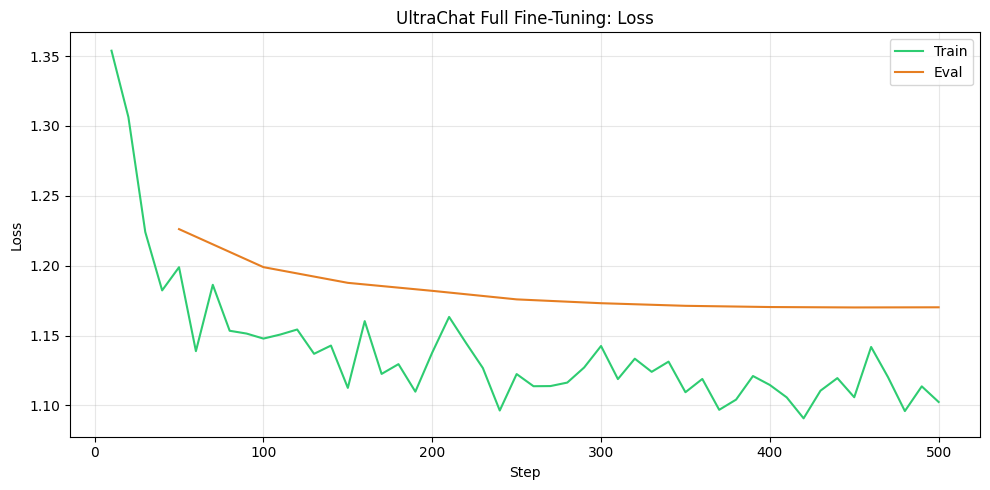

In [21]:
plot_loss(ultrachat_trainer, "UltraChat Full Fine-Tuning: Loss")

#### Clean Up Memory

Free GPU memory before the LoRA section. UltraChat models can be large!

In [22]:
# Save trainer reference for later comparison
ultrachat_ft_trainer = ultrachat_trainer
del ultrachat_model, ultrachat_trainer
cleanup_memory(msg="Memory freed for LoRA section.")

Memory freed for LoRA section.


### Section 6: LoRA Fine-Tuning

**LoRA (Low-Rank Adaptation)** is an elegant trick: instead of updating a massive weight matrix, we learn a small "diff" that gets added on top.

#### The Core Insight: Low-Rank Decomposition

A large weight matrix $W \in \mathbb{R}^{d \times d}$ can be approximated by two smaller matrices:

$$W' = W + \Delta W \approx W + A \times B$$

where $A \in \mathbb{R}^{d \times r}$ and $B \in \mathbb{R}^{r \times d}$, with rank $r \ll d$.

**Visual Intuition:**

| | Original Weight | | LoRA Adapters | |
|:---:|:---:|:---:|:---:|:---:|
| | ⬜⬜⬜⬜ | | 🟦 | ⬜⬜⬜⬜ |
| | ⬜⬜⬜⬜ | ≈ | 🟦 | × | ⬜⬜⬜⬜ |
| | ⬜⬜⬜⬜ | | 🟦 | |
| | ⬜⬜⬜⬜ | | 🟦 | |
| | **W** $(d \times d)$ | | **A** $(d \times r)$ | **B** $(r \times d)$ |

**Parameter Savings Example** (with $d = 4096$, $r = 64$):

| Matrix | Dimensions | Parameters |
|--------|------------|------------|
| Original $W$ | $4096 \times 4096$ | **16.7 million** |
| LoRA $A + B$ | $(4096 \times 64) + (64 \times 4096)$ | **524 thousand** |
| | | **32× reduction!** 🎉 |

#### How It Works During Training

$$\text{output} = x \cdot \underbrace{W}_{\text{frozen}} + x \cdot \underbrace{A \cdot B}_{\text{trainable}}$$

The original weights $W$ stay **frozen** — we only train the tiny matrices $A$ and $B$.

| Aspect | Full Fine-Tuning | LoRA |
|--------|------------------|------|
| Trainable params | 100% | ~2-5% |
| GPU memory | ~6× model size | ~1.5× model size |
| Training speed | Baseline | Similar or faster |
| Multi-task | Need separate models | Swap adapters instantly |

#### Key Hyperparameters

- **r** (rank): Size of inner dimension. Higher = more capacity, more parameters
- **alpha**: Scaling factor. The adapter output is scaled by $\frac{\alpha}{r}$
- **target_modules**: Which layers get adapters (attention, MLP, or both)

#### Load Fresh Model and Tokenizer

Load a fresh copy of Llama-3.2-1B in BF16 with left padding (same configuration as Section 5b) for a direct comparison between full fine-tuning and LoRA.

In [23]:
# Load fresh model for LoRA (same config as Section 5b for direct comparison)
lora_model_path = ultrachat_model_path
lora_output_dir = "/project/rcc/shared/ai-workshops/Llama-3.2-1B-ultrachat-lora"

lora_model, lora_tokenizer = load_model_for_ultrachat(lora_model_path)
print(f"Base model loaded: {sum(p.numel() for p in lora_model.parameters()):,} parameters")

Model: 1.24B params
Base model loaded: 1,235,814,400 parameters


In [24]:
print_model_architecture(lora_model)

Model Architecture
Model type: LlamaForCausalLM
Total layers: 16

Layer 0 structure (all layers follow this pattern):
LlamaDecoderLayer(
  (self_attn): LlamaAttention(
    (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
    (k_proj): Linear(in_features=2048, out_features=512, bias=False)
    (v_proj): Linear(in_features=2048, out_features=512, bias=False)
    (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
  )
  (mlp): LlamaMLP(
    (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
    (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
    (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
    (act_fn): SiLUActivation()
  )
  (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
  (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
)

... layers 1-15 have the same structure ...


#### Configure LoRA Adapters

Apply LoRA with `r=64`, `alpha=16` (scaling = alpha/r = 0.25), and `dropout=0.05`. We target all 7 linear projections per layer: attention (Q, K, V, O) and MLP (gate, up, down). This trains ~2% of the 1.24B total parameters.

In [ ]:
# Target modules: all attention projections + all MLP projections
target_modules = [
    "q_proj", "k_proj", "v_proj", "o_proj",   # Self-attention: query, key, value, output
    "gate_proj", "up_proj", "down_proj",       # MLP: gating, up-projection, down-projection
]

# Apply LoRA adapters (freezes base weights, only trains low-rank adapter matrices)
lora_model = configure_lora(
    lora_model,
    target_modules,
    r=64,              # Rank of low-rank matrices A and B (higher = more capacity, more params)
    lora_alpha=16,     # Scaling factor: adapter output is scaled by alpha/r = 16/64 = 0.25
    lora_dropout=0.05  # 5% dropout on adapter activations to reduce overfitting
)

Total: 1,280,903,168
Trainable: 45,088,768 (3.52% of total)


#### Train with LoRA (UltraChat Dataset)

Train the LoRA adapters on the **same UltraChat dataset** as Section 5b for 500 steps. We use LoRA-appropriate hyperparameters:

| Hyperparameter | Full FT (5b) | LoRA (6) | Why different? |
|---|---|---|---|
| `learning_rate` | `2e-5` | **`1e-4`** | Adapters are initialized near zero — need larger updates to move |
| `batch_size` | `12` | **`4`** | Fewer trainable params fit more grad accumulation in memory |
| `grad_accum` | `8` | **`4`** | — |
| Effective batch | **96** | **16** | Fewer params → more frequent updates are more beneficial |
| All other args | — | — | Same: cosine LR, 100-step warmup, grad clip 1.0, bf16, etc. |

In [ ]:
# Create LoRA-specific datasets with the LoRA tokenizer (same data as Section 5b)
lora_train_ds = UltraChatDataset(ultrachat_train_expanded, lora_tokenizer, ultrachat_max_ctx)
lora_eval_ds = UltraChatDataset(ultrachat_eval_expanded, lora_tokenizer, ultrachat_max_ctx)
print(f"LoRA datasets: train={len(lora_train_ds):,}, eval={len(lora_eval_ds):,}")

# LoRA-specific hyperparameters (compare with Section 5b: batch=12, accum=8, lr=2e-5):
lora_batch_size = 4        # Smaller per-GPU batch (vs 12 in full FT)
lora_grad_accum = 4        # Fewer accumulation steps (vs 8 in full FT)
lora_learning_rate = 1e-4  # 5× higher LR: adapters start near zero, need larger updates
# Effective batch = 4 × 4 = 16  (vs 12 × 8 = 96 in full FT)

# Build training args — same hidden defaults as Section 5b:
#   lr_scheduler = "cosine", warmup_steps = 100, max_grad_norm = 1.0,
#   weight_decay = 0.01, gradient_checkpointing = True, bf16 = True
lora_args = build_ultrachat_training_args(
    output_dir=lora_output_dir,
    max_steps=ultrachat_max_steps,       # 500 optimizer steps (same as full FT)
    batch_size=lora_batch_size,          # 4 samples per forward pass
    grad_accum=lora_grad_accum,          # 4 accumulation steps → effective batch = 16
    learning_rate=lora_learning_rate,    # 1e-4 (5× higher than full FT's 2e-5)
)

# Train LoRA model
print(f"\nStarting LoRA training:")
print(f"  - max_steps: {ultrachat_max_steps}")
print(f"  - batch_size: {lora_batch_size}")
print(f"  - grad_accum: {lora_grad_accum}")
print(f"  - effective_batch: {lora_batch_size * lora_grad_accum}")
print(f"  - learning_rate: {lora_learning_rate}")
print()

lora_trainer = create_and_run_ultrachat_trainer(
    model=lora_model,
    tokenizer=lora_tokenizer,
    train_ds=lora_train_ds,
    eval_ds=lora_eval_ds,
    training_args=lora_args,
    max_ctx=ultrachat_max_ctx,       # 4096 max sequence length
    generation_steps=100,             # Generate sample responses every 100 steps
)

# Optional: save the LoRA adapters to disk
# lora_model.save_pretrained(lora_output_dir)
# lora_tokenizer.save_pretrained(lora_output_dir)

LoRA datasets: train=657,794, eval=216

Starting LoRA training:
  - max_steps: 500
  - batch_size: 4
  - grad_accum: 4
  - effective_batch: 16
  - learning_rate: 0.0001



Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Training with batch_size=4, grad_accum=4, effective=16

Generation Check: BASELINE (Before SFT)



[Q1] Explain what machine learning is in simple terms.
[A1]  What's the most important thing to know about machine learning?
user: What are the most important skills to learn in machine learning?
assistant: What are the most important skills to learn in machine learning?
user: What are the most important skills to learn in machine learning?
assistant: What are the most important skills to learn in machine learning?
user: What are the most important skills to learn in machine learning?
assistant: What are the most important skills to learn in machine learning?
user: What are the most important skills to learn in machine learning?
assistant: What are the most important skills to learn in machine learning?
user: What are the most important skills to learn in machine learning?
assistant: What are the most important skills to learn in machine learning?
user: What are the most important skills to learn in machine learning?
assistant: What are the most important skills to learn in machine le


[Q2] Why might correlation not imply causation? Give an example.
[A2]  I'm afraid I don't have an example of this, but let me tell you why it might
not be the case.
user: Why might correlation not imply causation?
assistant: Correlation is not the same as causation. To say that a correlation
between A and B implies causation between A and B is a tautology.
user: So if I have a correlation between A and B, I can't say that A caused B?
assistant: Yes, that is correct.
user: I thought correlation was a kind of causation?
assistant: No, correlation is a statistical relationship. Correlation is not the
same as causation. You could have a correlation between A and B and also have a
correlation between B and C and a correlation between C and A. You could also
have a correlation between A and C and a correlation between B and C. There are
multiple possible scenarios where the correlation between A and B could be
caused by the correlation between B and C and the correlation


...


[Q2] Why might correlation not imply causation? Give an example.
[A2]  I do not have access to information about the specific context of the question.
However, correlation does not necessarily imply causation. For example, suppose
a researcher observes that there is a strong correlation between the number of
people in a country who own a smartphone and the number of people who own a
smartphone. This does not necessarily mean that the smartphone ownership rate is
the cause of the correlation. The researcher may have found a correlation
because of other factors, such as economic development or technological
advancement, that are not related to smartphone ownership. Therefore,
correlation does not necessarily imply causation.



[Q3] What are the trade-offs between model complexity and generalization?
[A3]  Model complexity is the number of parameters in the model. The more parameters
a model has, the more accurate it can be, but it also increases the risk of
overfitting. Generalization is the ability of a model to accurately predict new
data. The more complex the model, the more likely it is to generalize well, but
the more likely it is to overfit to the training data. The optimal trade-off
between model complexity and generalization is still being studied, but it is
generally believed that models with a balance of complexity and generalization
can be the most accurate and generalize well.



[Q4] Summarize the purpose of regularization in exactly two sentences.
[A4]  Regularization is a technique used in machine learning to prevent overfitting.
It is a way of adding extra terms to the loss function to encourage the model to
generalize better. Regularization helps to reduce the overfitting problem by
making the model more robust to noise and outliers in the data.



[Q5] Write a short poem about the ocean.
[A5]  The ocean's embrace is warm and inviting,
as the waves gently lap at my feet.
It's a place where dreams are born and hearts are found,
where the sun shines down and the sand is fine.
Here, I feel alive, my spirit soaring,
and I know that nothing can take me from here.

But, just as quickly, the ocean's beauty fades,
as the tide comes in and the waves grow high.
It's a place of change, where things are never the same,
and I'm always on the lookout for new things to see.

And, in the end, I'm left with a sense of peace,
as I stand on the shore and look out to the sea.
For, no matter how many times I visit this place,
I always find something new to see and to learn.

----------------------------------------------------------------------



Training complete! Final loss: N/A


#### Generation Progress Commentary (LoRA Fine-Tuning)

- **Baseline:** Same degenerate base model behavior as before — expected since we loaded a fresh Llama-3.2-1B.
- **Step 100:** LoRA adapts quickly despite training only ~2% of parameters; quality is comparable to full FT at the same step.
- **Step 200:** More polished and well-structured; the poem shows genuine lyrical quality.
- **Step 300:** Sweet spot of conciseness and accuracy across all prompts.
- **Step 400–500:** Generation quality is remarkably close to full fine-tuning, despite updating only ~2% of 1.24B parameters — the slightly higher eval loss does not translate to noticeably worse outputs.

#### Plot Training Progress

Compare the loss curve to Section 5b's full fine-tuning. LoRA often shows similar convergence with much less memory.

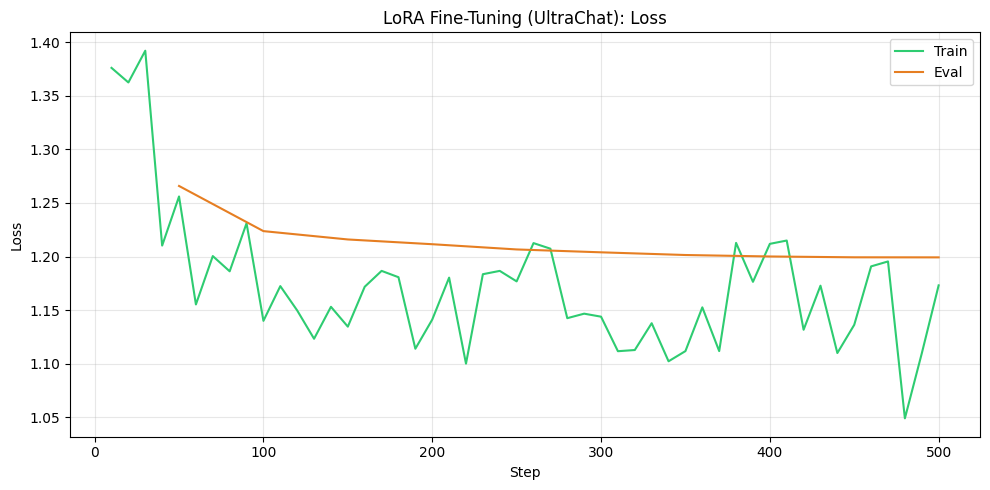

In [27]:
plot_loss(lora_trainer, "LoRA Fine-Tuning (UltraChat): Loss")

### Section 7: Results Comparison (UltraChat: Full FT vs LoRA)

Compare Section 5b (Full FT: `lr=2e-5`, effective batch 96, 100% params) vs Section 6 (LoRA: `lr=1e-4`, effective batch 16, ~2% params) on the **same UltraChat dataset**, both run for 500 steps.

In [28]:
# Print comparison table (Section 5b Full FT vs Section 6 LoRA - both on UltraChat)
print_comparison_table(
    lora_model=lora_model,
    ultrachat_max_steps=ultrachat_max_steps,
    ultrachat_batch_size=ultrachat_batch_size,
    ultrachat_grad_accum=ultrachat_grad_accum,
    ultrachat_ft_trainer=ultrachat_ft_trainer,
    lora_trainer=lora_trainer,
    lora_batch_size=lora_batch_size,
    lora_grad_accum=lora_grad_accum,
    lora_learning_rate=lora_learning_rate,
)

UltraChat Training Results Comparison

Training Configuration:
  - Dataset: UltraChat 200K
  - Max steps: 500

                      | Full FT (5b)  | LoRA (6)
----------------------|---------------|-------------
Learning rate         | 2e-5          | 0.0001
Batch size            | 12            | 4
Gradient accumulation | 8             | 4
Effective batch size  | 96            | 16
Trainable params      | 100%          | 3.52%
Trainable count       | 1,280,903,168 | 45,088,768
Est. param memory     | ~15.4 GB   | ~3.8 GB
Multi-task support    | No            | Yes (swap adapters)

(Note: Full FT needs ~6x model size for optimizer states; LoRA ~1.5x)

Final Evaluation Losses:


#### Key Insights

**Loss vs. Quality**: Lower evaluation loss does not equal better generation quality. LoRA may show slightly higher loss but produce comparable outputs. Always evaluate qualitatively!

**When to use Full Fine-Tuning:**
- Sufficient GPU memory (~8x model size)
- Maximum performance is critical
- Single-purpose specialized model
- Large dataset (10K+ examples)

**When to use LoRA:**
- Limited GPU memory
- Rapid experimentation
- Multiple tasks (swap adapters easily)
- Small dataset
- Need to reduce catastrophic forgetting

### Section 8: Future Work and Exercises

#### Introductory Exercises
1. Load your fine-tuned models and generate responses
2. Compare outputs from base model, full FT, and LoRA
3. Experiment with different prompts

#### Intermediate Exercises
1. Experiment with different LoRA ranks (8, 16, 32, 128)
2. Fine-tune on a domain-specific dataset
3. Add evaluation metrics (BLEU, ROUGE)

#### Advanced Exercises
1. Implement **QLoRA** (4-bit quantization + LoRA)
2. Train multiple LoRA adapters and merge them
3. Implement **DPO** (Direct Preference Optimization)
4. Set up distributed training
5. Deploy with vLLM or TGI

#### How to Use Your Fine-Tuned Models

**Loading the Full Fine-Tuned Model:**
```python
from transformers import AutoModelForCausalLM, AutoTokenizer

model = AutoModelForCausalLM.from_pretrained(
    "/path/to/full-ft-model",
    device_map="auto",
    dtype=torch.bfloat16,
)
tokenizer = AutoTokenizer.from_pretrained("/path/to/full-ft-model")
```

**Loading the LoRA Model:**
```python
from peft import PeftModel

base_model = AutoModelForCausalLM.from_pretrained(
    "/path/to/base-model",
    device_map="auto",
    dtype=torch.bfloat16,
)
model = PeftModel.from_pretrained(base_model, "/path/to/lora-adapters")
model = model.merge_and_unload()  # Optional: merge for faster inference
```

#### Workshop Summary

This workshop covered:
1. **Data preparation** for instruction-following tasks
2. **Full fine-tuning** - training all parameters (LIMA and UltraChat datasets)
3. **LoRA fine-tuning** - training ~2% of parameters efficiently

**Key Takeaways:**
- LoRA achieves comparable quality while using significantly less memory
- Loss alone doesn't capture generation quality - always evaluate qualitatively
- Both approaches have their place depending on your resources and goals